In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
import healpy as hp

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [69]:
# reader = csiborgtools.read.CSiBORG2Field(17417, "main")
reader = csiborgtools.read.Carrick2015Field()

field = reader.density_field(MAS="SPH", grid=1024)

In [70]:
nside = 128
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))

ra = np.rad2deg(phi)
dec = np.rad2deg(np.pi/2 - theta)

el, b = csiborgtools.radec_to_galactic(ra, dec)
angpos = np.array([el, b]).T
# angpos = np.array([ra, dec]).T

rmin = 85 * 0.6771
rmax = 150 * 0.6771
dr = 0.1
boxsize = csiborgtools.simname2boxsize("Carrick2015")
# boxsize = csiborgtools.simname2boxsize("csiborg2_main")

field_map = csiborgtools.field.make_sky(field, angpos, rmin, rmax, dr, boxsize)


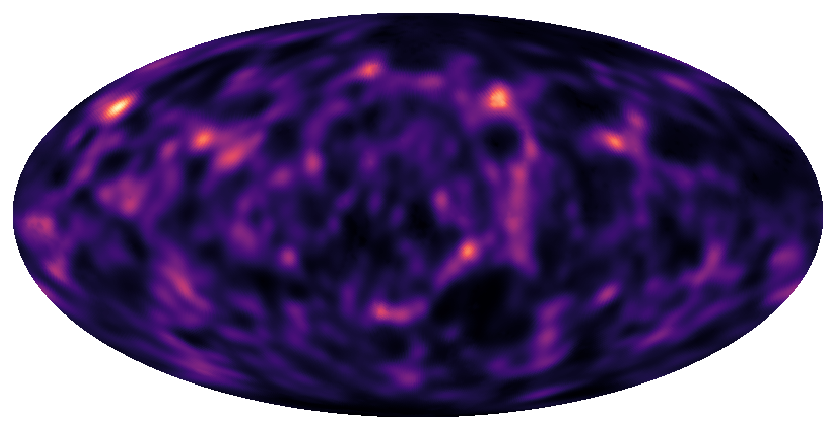

In [72]:
hp.mollview(field_map, rot=90, cmap="magma", title="", cbar=False)
plt.savefig("carrick_projection.png", dpi=500, bbox_inches="tight")